# Lab 20 — Block Codes: Hamming, SECDED, CRCs, Finite Fields and Reed–Solomon

**Companion to Chapter 14** (*Classical Error-Control Codes*).
**Time needed:** about 90 minutes. **Difficulty:** core.

The algebraic codes of the 1950s and 1960s are still everywhere: a Hamming-derived SECDED code guards every word of
server memory, a CRC ends every Ethernet frame and every 5G transport block, BCH codes clean up the residual errors
of the DVB-S2 LDPC decoder, and Reed–Solomon codes protect QR codes, CDs, deep-space links and RAID-6 arrays. This lab
builds them from the bits up. You will encode and decode Hamming codes by syndrome and watch them miscorrect, measure
what a (72,64) SECDED memory code does with one, two and three bit flips, calculate CRCs the way the standards define them
(all five conventions), play with GF($2^m$) arithmetic, decode BCH and Reed–Solomon codes step by step, and see how
interleaving turns a burst that destroys an image into one the decoder shrugs off.
Library code: `commlib/blockcodes.py` (linear codes, SECDED, interleavers, performance formulas) and `commlib/gf.py`
(finite fields, BCH, Reed–Solomon, CRCs).

### What you will learn
1. Encode with $\mathbf{G}$, check with $\mathbf{H}$, decode by syndrome, and predict when a decoder miscorrects.
2. Quantify SECDED behaviour (correct / detect / silently corrupt) for 1, 2 and 3 errors.
3. Compute standard CRCs with every convention, and measure what a CRC does and does not detect.
4. Do arithmetic in GF($2^m$) with log/antilog tables and find minimal polynomials.
5. Decode BCH and Reed–Solomon codes (syndromes, Berlekamp–Massey, Chien, Forney), with errors and erasures.
6. Use interleaving to spread bursts across codewords.

### Prerequisites
Modulo-2 arithmetic, matrices. Lab 8 (Hamming, CRC-11 and convolutional codes, briefly). Chapter 14.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Hamming codes: generator, parity checks and syndromes | yes |
| 2 | SECDED in computer memory | |
| 3 | A CRC calculator, and what CRCs detect | yes |
| 4 | The GF($2^m$) playground | yes |
| 5 | BCH codes | |
| 6 | Reed–Solomon codes: errors, erasures, the cliff | yes |
| 7 | Bursts and interleaving | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import gf
from commlib import blockcodes as bc
from commlib import labkit as lk

rng = lk.setup(seed=20, lab="20")
bstr = lambda v: "".join(str(int(b)) for b in v)

Lab 20 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 20


## 1. Hamming codes: generator, parity checks and syndromes

A systematic $(n,k)$ code has $\mathbf{G} = [\mathbf{I}_k \mid \mathbf{P}]$ and $\mathbf{H} = [\mathbf{P}^{\mathsf T}\mid\mathbf{I}_{n-k}]$,
with $\mathbf{c}=\mathbf{u}\mathbf{G}$ and $\mathbf{c}\mathbf{H}^{\mathsf T}=\mathbf{0}$. A received word
$\mathbf{r}=\mathbf{c}\oplus\mathbf{e}$ has **syndrome** $\mathbf{s}=\mathbf{r}\mathbf{H}^{\mathsf T}=\mathbf{e}\mathbf{H}^{\mathsf T}$: it
depends only on the error. The Hamming (7,4) code's seven columns of $\mathbf{H}$ are the seven nonzero 3-bit vectors, so
a single error at position $j$ produces syndrome = column $j$, and the decoder flips that bit. Two errors produce the
sum of two columns, which is a *third* column: the decoder confidently flips a correct bit (a **miscorrection**).

Chapter 14's worked example: $\mathbf{u}=1011 \to \mathbf{c}=1011\,010$; flip bit 6 to get $1011\,000$, syndrome $010$.

G rows
1000110
0100101
0010011
0001111


H rows
1101100
1011010
0111001


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

,bits
message u,1011
codeword c,1011010
error e,0000010
received r,1011000
syndrome s = r H^T,010
decoder output,1011010
result,correct


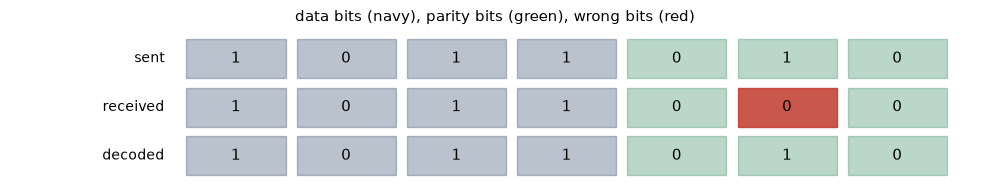

In [3]:
ham = bc.hamming_code(3)
lk.table([[bstr(r)] for r in ham.G], ["G rows"], title="Hamming (7,4): G = [I | P]")
lk.table([[bstr(r)] for r in ham.H], ["H rows"], title="H = [P^T | I] (column j = syndrome of an error in bit j)")

def hamming_demo(msg=11, flip_a=6, flip_b=0):
    u = np.array([(msg >> (3 - i)) & 1 for i in range(4)])
    c = ham.encode(u)
    e = np.zeros(7, int)
    for f in (flip_a, flip_b):
        if f:
            e[f - 1] ^= 1
    r = (c + e) % 2
    uh, s, _ = ham.decode(r)
    chat = ham.encode(uh)
    verdict = "correct" if np.array_equal(uh, u) else ("MISCORRECTED (wrong codeword, no warning)" if e.sum() else "?")
    lk.table([["message u", bstr(u)], ["codeword c", bstr(c)], ["error e", bstr(e)], ["received r", bstr(r)],
              ["syndrome s = r H^T", bstr(s)], ["decoder output", bstr(chat)], ["result", verdict if e.any() else "no error"]],
             ["", "bits"])
    f, ax = lk.fig((10, 2.0))
    for row, (v, lab) in enumerate([(c, "sent"), (r, "received"), (chat, "decoded")]):
        for j in range(7):
            bad = v[j] != c[j]
            ax.add_patch(plt.Rectangle((j, 2 - row), 0.9, 0.8, color=lk.RED if bad else (lk.NAVY if j < 4 else lk.GREEN),
                                       alpha=0.85 if bad else 0.3))
            ax.text(j + 0.45, 2.4 - row, str(v[j]), ha="center", va="center", fontsize=11)
        ax.text(-0.2, 2.4 - row, lab, ha="right", va="center")
    ax.set_xlim(-1.6, 7.2); ax.set_ylim(-0.1, 3); ax.axis("off")
    ax.set_title("data bits (navy), parity bits (green), wrong bits (red)")
    lk.show(f)

lk.interact(hamming_demo, msg=lk.islider(11, 0, 15, 1, "message (0-15)"),
            flip_a=lk.islider(6, 0, 7, 1, "flip bit (0 = none)"), flip_b=lk.islider(0, 0, 7, 1, "and bit (0 = none)"))

**What you should see.** With the defaults the decoder fixes bit 6 (syndrome 010, the sixth column). Add a second flip
(e.g. bit 1 and bit 2): the syndrome 011 points at bit 3 and the decoder outputs a wrong codeword three bits away from
the right one. Below, the weight distribution $A_w$ of the (7,4) code (1, 0, 0, 7, 7, 0, 0, 1: $d_{\min}=3$) and the
decoded bit error rate on a binary symmetric channel, Monte Carlo against the standard approximation
$P_b \approx \sum_{i>t}\frac{i+t}{n}\binom{n}{i}p^i(1-p)^{n-i}$.

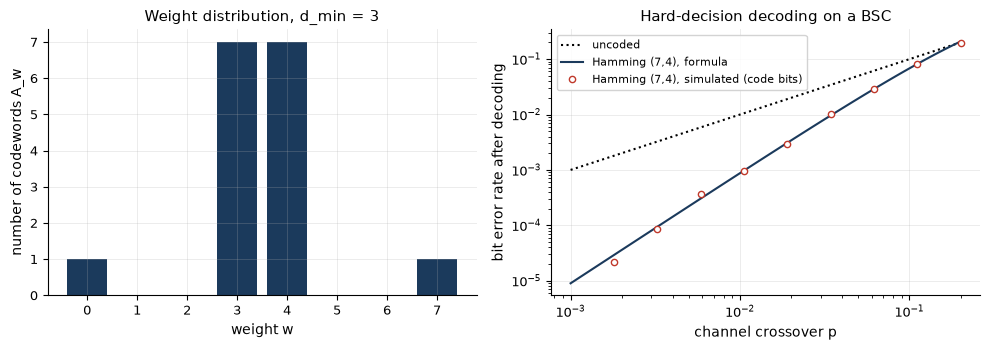

In [5]:
A = ham.weight_distribution()
ps = np.logspace(-3, np.log10(0.2), 10)
U = rng.integers(0, 2, (20000, 4))
C = ham.encode(U)
mc = []
for p in ps:
    R = (C + (rng.random(C.shape) < p)) % 2
    S = ham.syndrome(R)
    col = {bstr(ham.H[:, j]): j for j in range(7)}
    E = np.zeros_like(R)
    for i, s in enumerate(S):
        if s.any():
            E[i, col[bstr(s)]] = 1
    mc.append(np.mean(((R + E) % 2) != C))
f, ax = lk.fig("row2", 1, 2)
ax[0].bar(range(8), A, color=lk.NAVY); ax[0].set_xlabel("weight w"); ax[0].set_ylabel("number of codewords A_w")
ax[0].set_title(f"Weight distribution, d_min = {ham.dmin()}")
pp = np.logspace(-3, np.log10(0.2), 100)
ax[1].loglog(pp, pp, "k:", label="uncoded")
ax[1].loglog(pp, bc.block_hard_ber(7, 1, pp), color=lk.NAVY, label="Hamming (7,4), formula")
ax[1].loglog(ps, mc, "o", color=lk.RED, mfc="white", label="Hamming (7,4), simulated (code bits)")
ax[1].set_xlabel("channel crossover p"); ax[1].set_ylabel("bit error rate after decoding"); ax[1].legend(fontsize=8)
ax[1].set_title("Hard-decision decoding on a BSC")
lk.show(f)

### Try it yourself 1.1
How many distinct syndromes does the Hamming (15,11) code have, and how many single-error patterns? Check that it is a
*perfect* code: enter the number of nonzero syndromes (`bc.hamming_code(4)` builds it).

In [7]:
answer_1_1 = None
lk.check("1.1 nonzero syndromes of Hamming (15,11)", answer_1_1, 2 ** bc.hamming_code(4).r - 1, atol=0)

[TODO] 1.1 nonzero syndromes of Hamming (15,11): not attempted yet: replace the None with your answer

## 2. SECDED in computer memory

Adding an overall parity bit makes the extended Hamming code ($d_{\min}=4$). If every column of $\mathbf{H}$ has **odd**
weight (Hsiao's construction), then an odd-weight syndrome means an odd number of errors (assume one, correct it) and
a nonzero even-weight syndrome means an even number (detect, do not touch). A DDR ECC module stores 64 data bits with 8
check bits: a (72,64) Hsiao code. We hit one codeword with 1, 2 and 3 random bit flips many times.

In [9]:
sec = bc.hsiao_secded_72_64()
lk.table([[f"row {i}", bstr(sec.H[i, :64]), int(sec.H[i].sum())] for i in range(8)],
         ["", "H, data columns (64)", "row weight"], title="Hsiao (72,64): every column odd weight, rows balanced")
u = rng.integers(0, 2, 64)
c = sec.encode(u)
rows = []
for k in (1, 2, 3, 4):
    st = Counter()
    for _ in range(4000):
        r = c.copy(); r[rng.choice(72, k, replace=False)] ^= 1
        m, _, status = sec.decode(r)
        st["silent corruption" if status != "detected" and not np.array_equal(m, u) else status] += 1
    rows.append([k] + [100 * st[s] / 4000 for s in ["corrected", "detected", "silent corruption"]])
lk.table(rows, ["bit flips", "corrected (%)", "detected (%)", "silent data corruption (%)"], fmt=".1f")

,"H, data columns (64)",row weight
row 0,1111111111111111111110000000000000000000000000000000000011011010,27
row 1,1111110000000000000001111111111111110000000000000000000011010110,27
row 2,1000001111100000000001111100000000001111111111000000000010110110,27
row 3,0100001000011110000001000011110000001111000000111111000010110101,27
row 4,0010000100010001110000100010001110001000111000111000111010101101,27
row 5,0001000010001001001100010001001001100100100110100110110101101101,27
row 6,0000100001000100101010001000100101010010010101010101101101101011,27
row 7,0000010000100010010110000100010010110001001011001011011101011011,27


bit flips,corrected (%),detected (%),silent data corruption (%)
1,100.0,0.0,0.0
2,0.0,100.0,0.0
3,0.0,43.8,56.2
4,0.0,99.2,0.8


**What you should see.** One flip: always corrected. Two: always detected (the "corrected" column stays at zero).
Three: more than half are "corrected" into the *wrong* data with no warning, the pitfall in Chapter 14. That is why
memories interleave physically adjacent bits into different words, and why the triple-error probability per word,
not the single-error rate, sets the silent-corruption rate.

### Try it yourself 2.1
With independent bit flips of probability $p = 10^{-6}$ per bit, what is the probability that a 72-bit word suffers
exactly three flips? (`math.comb` helps.) Compare it with the probability of exactly one.

In [11]:
from math import comb
answer_2_1 = None
lk.check("2.1 P(exactly 3 flips in 72 bits), p = 1e-6", answer_2_1, comb(72, 3) * 1e-18 * (1 - 1e-6) ** 69, rtol=0.02)

[TODO] 2.1 P(exactly 3 flips in 72 bits), p = 1e-6: not attempted yet: replace the None with your answer

## 3. A CRC calculator, and what CRCs detect

A CRC appends the remainder of $x^r u(x)$ divided by the generator $g(x)$ (degree $r$). Chapter 14's hand example:
$u = 1101011011$, $g = x^4+x+1$ gives remainder 1110. A *standard* CRC adds five conventions (Williams' "Rocksoft model"):
initial register value, input reflection, output reflection, final XOR, and the *check* value, the CRC of the ASCII
string "123456789", which every catalogue lists so you can test your implementation.

In [13]:
lk.table([["hand example: 1101011011, g = 10011", bstr(bc.crc_append([1, 1, 0, 1, 0, 1, 1, 0, 1, 1], [1, 0, 0, 1, 1])[-4:])]],
         ["", "CRC"])
rows = []
for name, (w, p, i0, ri, ro, xo, chk) in gf.CRC_CATALOG.items():
    v = gf.crc_bits(b"123456789", w, p, i0, ri, ro, xo)
    rows.append([name, f"{p:#x}", f"{i0:#x}", ri, ro, f"{xo:#x}", f"{v:#0{w // 4 + 2}x}", "ok" if v == chk else "MISMATCH"])
lk.table(rows, ["CRC", "poly", "init", "refin", "refout", "xorout", 'CRC("123456789")', "check"])

def crc_calc(text="Hello, world", crc="CRC-32 (IEEE 802.3)", init_override="catalogue"):
    w, p, i0, ri, ro, xo, _ = gf.CRC_CATALOG[crc]
    variants = {"catalogue": (i0, ri, ro, xo), "plain (init 0, no reflection, no xor)": (0, False, False, 0)}
    a, b, c_, d = variants[init_override]
    v = gf.crc_bits(text.encode(), w, p, a, b, c_, d)
    lk.table([[crc, init_override, f"{v:#0{w // 4 + 2}x}"]], ["CRC", "conventions", f"CRC of {text!r}"])

lk.interact(crc_calc, text="Hello, world", crc=lk.choice(list(gf.CRC_CATALOG), "CRC-32 (IEEE 802.3)", "CRC"),
            init_override=lk.choice(["catalogue", "plain (init 0, no reflection, no xor)"], "catalogue", "conventions"))

,CRC
"hand example: 1101011011, g = 10011",1110


CRC,poly,init,refin,refout,xorout,"CRC(""123456789"")",check
CRC-8/ATM (HEC),0x7,0x0,False,False,0x0,0xf4,ok
CRC-16/CCITT-FALSE,0x1021,0xffff,False,False,0x0,0x29b1,ok
CRC-16/KERMIT,0x1021,0x0,True,True,0x0,0x2189,ok
CRC-16/ARC,0x8005,0x0,True,True,0x0,0xbb3d,ok
CRC-24/LTE-A,0x864cfb,0x0,False,False,0x0,0xcde703,ok
CRC-32 (IEEE 802.3),0x4c11db7,0xffffffff,True,True,0xffffffff,0xcbf43926,ok
CRC-32C (Castagnoli),0x1edc6f41,0xffffffff,True,True,0xffffffff,0xe3069283,ok


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

CRC,conventions,"CRC of 'Hello, world'"
CRC-32 (IEEE 802.3),catalogue,0xe79aa9c2


**What a CRC detects.** Because the code is linear, an error pattern $e(x)$ goes undetected exactly when $g(x)$ divides it.
So we can test detection by dividing error patterns alone. With the 8-bit ATM HEC polynomial $x^8+x^2+x+1 = (x+1)(x^7+x^6+\dots)$
on 64-bit frames: all single errors, all odd-weight errors (the $(x+1)$ factor), all bursts of length $\le 8$ are caught;
longer bursts and random corruption slip through with probability close to $2^{-8} = 0.39\%$ (bursts of exactly $r+1 = 9$:
$2^{-7}$).

In [15]:
g_atm = 0b100000111
def undetected_rate(make_error, n=64, trials=20000):
    miss = 0
    for _ in range(trials):
        e = make_error(n)
        miss += (e != 0) and gf.gf2_polymod(e, g_atm) == 0
    return miss / trials
def burst(L):
    def mk(n):
        s = int(rng.integers(0, n - L + 1))
        inner = int(rng.integers(0, 2 ** max(L - 2, 0))) if L > 2 else 0
        pat = (1 << (L - 1)) | (inner << 1) | 1 if L > 1 else 1
        return pat << s
    return mk
def weight(w):
    return lambda n: sum(1 << int(b) for b in rng.choice(n, w, replace=False))
rows = [["single errors", undetected_rate(weight(1))], ["double errors", undetected_rate(weight(2))],
        ["triple errors (odd)", undetected_rate(weight(3))], ["4 errors", undetected_rate(weight(4))],
        ["burst length 8", undetected_rate(burst(8))], ["burst length 9", undetected_rate(burst(9))],
        ["burst length 12", undetected_rate(burst(12))],
        ["random 64-bit garbage", undetected_rate(lambda n: int(rng.integers(0, 2 ** 62)) | (int(rng.integers(0, 4)) << 62))]]
lk.table([[a, 100 * b] for a, b in rows], ["error type", "undetected (%)"], fmt=".3f",
         title="CRC-8 (x^8 + x^2 + x + 1) on 64-bit frames, 20 000 trials each (2^-8 = 0.391%, 2^-7 = 0.781%)")

error type,undetected (%)
single errors,0.000
double errors,0.000
triple errors (odd),0.000
4 errors,0.650
burst length 8,0.000
burst length 9,0.890
burst length 12,0.335
random 64-bit garbage,0.365


**What you should see.** Zero misses for single, double, triple and length-8 bursts; about 0.8% for length-9 bursts and
about 0.4% for long bursts and random garbage. Four-bit errors slip through at about $2^{-7}$ rather than $2^{-8}$: every
multiple of $g(x)$ has even weight, so the undetectable patterns are concentrated among the even-weight ones. The CRC's guarantee is structural for short patterns and
statistical ($2^{-r}$) for everything else: a 32-bit CRC lets one in four billion corrupted frames through.

### Try it yourself 3.1
Use `gf.crc_bits` to compute the CRC-16/CCITT-FALSE of the ASCII bytes `b"MDC"`. Enter it as an integer.

In [17]:
answer_3_1 = None
lk.check("3.1 CRC-16/CCITT-FALSE of b'MDC'", answer_3_1, gf.crc_bits(b"MDC", *gf.CRC_CATALOG["CRC-16/CCITT-FALSE"][:6]), atol=0)

[TODO] 3.1 CRC-16/CCITT-FALSE of b'MDC': not attempted yet: replace the None with your answer

## 4. The GF($2^m$) playground

GF($2^m$) is built from a primitive polynomial $p(x)$ of degree $m$: its root $\alpha$ generates every nonzero element as
$\alpha^0,\dots,\alpha^{2^m-2}$. Elements are $m$-bit vectors (polynomials in $\alpha$): **add** by XOR, **multiply** by adding
logarithms modulo $2^m-1$. The **minimal polynomial** of $\alpha^i$ is the product of $(x+\alpha^j)$ over its
conjugates $j \in \{i, 2i, 4i, \dots\}$ (a cyclotomic coset); these are the building blocks of BCH generators.

Chapter 14 worked example in GF(8): $\alpha^4+\alpha^5 = 110\oplus111 = 001 = 1$; $\alpha^4\alpha^5 = \alpha^9 = \alpha^2$;
$\alpha^2/\alpha^5 = \alpha^4$; $(\alpha^3)^{-1}=\alpha^4$.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

power,polynomial in a,vector,integer
a^0,1,001,1
a^1,a,010,2
a^2,a^2,100,4
a^3,a + 1,011,3
a^4,a^2 + a,110,6
a^5,a^2 + a + 1,111,7
a^6,a^2 + 1,101,5


cyclotomic coset,minimal polynomial
"[1, 2, 4]",x^3 + x + 1
"[3, 5, 6]",x^3 + x^2 + 1


expression,result
a^4 + a^5,1
a^4 * a^5,a^2
a^2 / a^5,a^4
1 / a^3,a^4


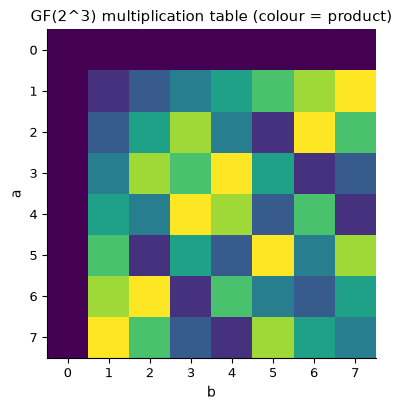

In [19]:
def gf_demo(m=3):
    F = gf.GF(m)
    lk.table([[f"a^{i}", p, v, d] for i, p, v, d in F.table()][:16], ["power", "polynomial in a", "vector", "integer"],
             title=f"GF(2^{m}) with p(x) = {gf.poly_str(F.prim)}" + (" (first 16 rows)" if m > 4 else ""))
    cos = []
    seen = set()
    for i in range(1, F.n):
        if i in seen:
            continue
        co = sorted({(i * (1 << k)) % F.n for k in range(m)}); seen.update(co)
        cos.append([str(co), gf.poly_str(F.minimal_poly(i))])
        if len(cos) == 8:
            break
    lk.table(cos, ["cyclotomic coset", "minimal polynomial"])
    a4, a5, a3 = F.alpha(4), F.alpha(5), F.alpha(3)
    lk.table([["a^4 + a^5", F.elem_str(F.add(a4, a5))], ["a^4 * a^5", F.elem_str(F.mul(a4, a5))],
              ["a^2 / a^5", F.elem_str(F.div(F.alpha(2), a5))], ["1 / a^3", F.elem_str(F.inv(a3))]], ["expression", "result"])
    M = np.array([[F.mul(a, b) for b in range(F.q)] for a in range(F.q)])
    f, ax = lk.fig((4.6, 4.2))
    ax.imshow(M, cmap="viridis", interpolation="nearest"); ax.grid(False)
    ax.set_title(f"GF(2^{m}) multiplication table (colour = product)"); ax.set_xlabel("b"); ax.set_ylabel("a")
    lk.show(f)

lk.interact(gf_demo, m=lk.islider(3, 2, 8, 1, "m"))

**What you should see.** For $m=3$ the four expressions give 1, $\alpha^2$, $\alpha^4$, $\alpha^4$, as in the chapter. For $m = 4$ the
minimal polynomials are $x^4+x+1$, $x^4+x^3+x^2+x+1$, $x^2+x+1$, $x^4+x^3+1$. The multiplication table looks random, which
is precisely the property that makes GF(256) the arithmetic of AES and RAID-6 as well as Reed–Solomon.

### Try it yourself 4.1
In GF(16) with $p(x)=x^4+x+1$, what is $\alpha^{7}\cdot\alpha^{12}$ written as a power $i$ of $\alpha$? Enter $i$.

In [21]:
answer_4_1 = None
F16 = gf.GF(4)
lk.check("4.1 a^7 * a^12 = a^i in GF(16)", answer_4_1, int(F16.log[F16.mul(F16.alpha(7), F16.alpha(12))]), atol=0)

[TODO] 4.1 a^7 * a^12 = a^i in GF(16): not attempted yet: replace the None with your answer

## 5. BCH codes

A $t$-error-correcting binary BCH code of length $2^m-1$ has generator $g(x) = \mathrm{lcm}\{m_1, m_3, \dots, m_{2t-1}\}$, so
$\alpha, \alpha^2, \dots, \alpha^{2t}$ are roots of every codeword. The decoder computes the syndromes
$S_j = r(\alpha^j)$, finds the error-locator polynomial $\Lambda(x)$ with Berlekamp–Massey, and finds its roots by the
Chien search. Chapter 14's example: the (15,7) code, all-zero codeword, errors at positions 3 and 10:
$S_1 = \alpha^{12}$, $S_3 = \alpha^7$, $\Lambda(x) = 1 + \alpha^{12}x + \alpha^{13}x^2$.

"BCH (15,7) worked example",
generator g(x),x^8 + x^7 + x^6 + x^4 + 1
"(n, k)","(15, 7)"
"S1, S2, S3, S4","a^12, a^9, a^7, a^3"
Lambda(x) (low first),"1, a^12, a^13"
errors corrected,2
decoded message all zero?,True


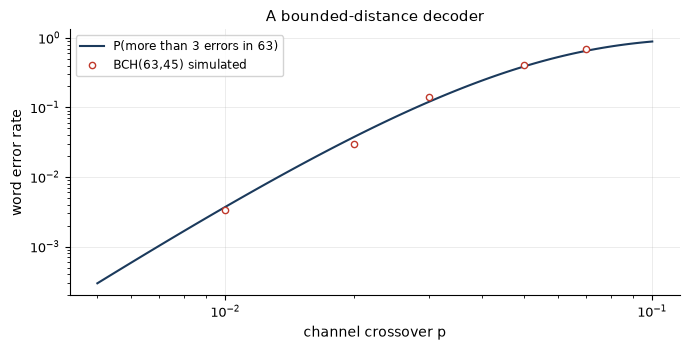

In [23]:
b157 = gf.BCH(4, 2)
F = b157.F
r = np.zeros(15, int); r[15 - 1 - 3] = 1; r[15 - 1 - 10] = 1     # e(x) = x^10 + x^3 (transmission order)
low = r[::-1].tolist()
S = [F.poly_eval(low, F.alpha(j)) for j in range(1, 5)]
lam, L = gf._berlekamp_massey(F, S)
mh, nc = b157.decode(r)
lk.table([["generator g(x)", gf.poly_str(b157.g)], ["(n, k)", f"({b157.n}, {b157.k})"],
          ["S1, S2, S3, S4", ", ".join(F.elem_str(s) for s in S)], ["Lambda(x) (low first)", ", ".join(F.elem_str(c) for c in lam)],
          ["errors corrected", nc], ["decoded message all zero?", not mh.any()]], ["BCH (15,7) worked example", ""])

# BCH (63,45), t = 3: Monte Carlo on a BSC against the bounded-distance formula
b63 = gf.BCH(6, 3)
ps = [0.01, 0.02, 0.03, 0.05, 0.07]
wer = []
for p in ps:
    fails = 0
    for _ in range(300):
        msg = rng.integers(0, 2, b63.k); cw = b63.encode(msg)
        rr = cw ^ (rng.random(63) < p)
        fails += not np.array_equal(b63.decode(rr)[0], msg)
    wer.append(fails / 300)
f, ax = lk.fig((7, 3.6))
pp = np.logspace(-2.3, np.log10(0.1), 100)
ax.loglog(pp, bc.word_error_bounded(63, 3, pp), color=lk.NAVY, label="P(more than 3 errors in 63)")
ax.loglog(ps, wer, "o", color=lk.RED, mfc="white", label="BCH(63,45) simulated")
ax.set_xlabel("channel crossover p"); ax.set_ylabel("word error rate"); ax.legend(); ax.set_title("A bounded-distance decoder")
lk.show(f)

**What you should see.** The syndromes and locator match the chapter's hand calculation, and the decoder repairs both
errors. For BCH(63,45) the simulated word error rate sits on the bounded-distance curve: the decoder corrects every
pattern of up to three errors and (almost) nothing beyond.

## 6. Reed–Solomon codes: errors, erasures, the cliff

Reed–Solomon codes work over symbols of GF($2^m$): an $(n,k)$ code corrects $\nu$ symbol errors and $e$ erasures whenever
$2\nu + e \le n-k$, the best possible (MDS). Chapter 14's worked example: RS(7,3) over GF(8), $b=1$, message
$(1,\alpha^2,\alpha^5)$ → codeword $(1,\alpha^2,\alpha^5,\alpha,\alpha,1,\alpha^5)$; add $\alpha^3$ at $x^5$ and $\alpha^6$ at $x^1$.

"RS(7,3) step by step",
g(x) (low first),"a^3, a^1, 1, a^3, 1"
codeword,"1, a^2, a^5, a^1, a^1, 1, a^5"
received,"1, a^5, a^5, a^1, a^1, a^2, a^5"
syndromes S1..S4,"a^3, a^5, a^1, a^5"
Lambda(x) (low first),"1, a^6, a^6"
error positions (index),"[1, 5]"
error values,"a^3, a^6"
decoded message,"1, a^2, a^5"


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

code,errors,erasures,2v + e vs n-k,decoded,
"RS(255,223)",10,0,20 vs 32,30/30,within the guarantee


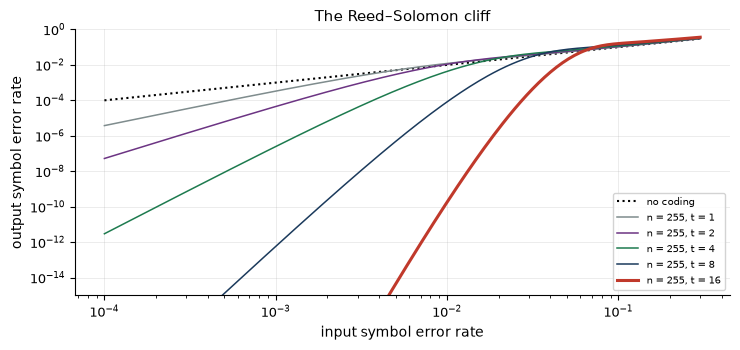

In [25]:
F8 = gf.GF(3)
rs73 = gf.ReedSolomon(7, 3, F8, fcr=1)
msg = [1, F8.alpha(2), F8.alpha(5)]
cw = rs73.encode(msg)
rx = cw.copy(); rx[7 - 1 - 5] ^= F8.alpha(3); rx[7 - 1 - 1] ^= F8.alpha(6)
mh, nc, det = rs73.decode(rx, return_detail=True)
es = lambda v: ", ".join(F8.elem_str(x) for x in v)
lk.table([["g(x) (low first)", es(rs73.g)], ["codeword", es(cw)], ["received", es(rx)], ["syndromes S1..S4", es(det["S"])],
          ["Lambda(x) (low first)", es(det["Lambda"])], ["error positions (index)", str(det["positions"])],
          ["error values", es(det["values"])], ["decoded message", es(mh)]], ["RS(7,3) step by step", ""])

def rs_demo(n_err=10, n_eras=0, t_code=16):
    rs = gf.ReedSolomon(255, 255 - 2 * t_code, gf.GF(8))
    ok = 0
    trials = 30
    for _ in range(trials):
        m_ = rng.integers(0, 256, rs.k); c_ = rs.encode(m_); r_ = c_.copy()
        pos = rng.choice(255, n_err + n_eras, replace=False)
        r_[pos] ^= rng.integers(1, 256, len(pos))
        er = list(pos[n_err:])
        ok += np.array_equal(rs.decode(r_, erasures=er)[0], m_)
    within = 2 * n_err + n_eras <= 2 * t_code
    lk.table([[f"RS(255,{rs.k})", n_err, n_eras, f"{2 * n_err + n_eras} vs {2 * t_code}", f"{ok}/{trials}",
               "within the guarantee" if within else "beyond n-k"]],
             ["code", "errors", "erasures", "2v + e vs n-k", "decoded", ""])
    ps = np.logspace(-4, np.log10(0.3), 200)
    f, ax = lk.fig((7.5, 3.6))
    ax.loglog(ps, ps, "k:", label="no coding")
    for t, col in zip([1, 2, 4, 8, 16], [lk.GRAY, lk.PURPLE, lk.GREEN, lk.NAVY, lk.RED]):
        ax.loglog(ps, bc.rs_ser_out(255, t, ps), color=col, lw=2.2 if t == t_code else 1.1, label=f"n = 255, t = {t}")
    ax.set_ylim(1e-15, 1); ax.set_xlabel("input symbol error rate"); ax.set_ylabel("output symbol error rate")
    ax.legend(fontsize=7.5); ax.set_title("The Reed–Solomon cliff")
    lk.show(f)

lk.interact(rs_demo, n_err=lk.islider(10, 0, 40, 1, "symbol errors"), n_eras=lk.islider(0, 0, 40, 1, "erasures"),
            t_code=lk.choice([8, 16], 16, "t (RS(255,239) or RS(255,223))"))

**What you should see.** The step-by-step table finds positions $x^5$ and $x^1$ (indices 1 and 5) and values $\alpha^3$, $\alpha^6$,
exactly as in the chapter. RS(255,223) decodes every word with up to 16 errors, or 32 erasures, or any mix with
$2\nu+e\le 32$; beyond that it *detects* failure almost always (the message comes back uncorrected). The cliff: with
$t=16$, an input symbol error rate of 1% becomes about $2	imes10^{-10}$ at the output, 2% gives $3	imes10^{-6}$, and 5% is hopeless.

### Try it yourself 6.1
Using `bc.rs_ser_out`, what output symbol error rate does RS(204,188) ($t=8$, DVB-T/DVB-S) give at an input symbol error
rate of $2\times10^{-3}$? (Use n = 204.)

In [27]:
answer_6_1 = None
lk.check("6.1 RS(204,188) output SER at 2e-3", answer_6_1, float(bc.rs_ser_out(204, 8, 2e-3)), rtol=0.05)

[TODO] 6.1 RS(204,188) output SER at 2e-3: not attempted yet: replace the None with your answer

## 7. Bursts and interleaving

Channels with memory (fades, scratches, impulse noise) produce **bursts**. A burst longer than $t$ symbols inside one
codeword defeats it, however few errors the channel makes on average. An **interleaver** writes $D$ codewords as the rows of
an array and sends it column by column, so a burst of $B$ symbols puts only about $B/D$ errors into each codeword. Here an
image of 96 rows × 223 bytes is protected row by row with RS(255,223), and the transmitted byte stream is hit by three bursts
of about 300 bytes. With interleaving depth $D = 96$ (the whole image) each burst puts only 3–4 errors in each codeword, so even a
codeword hit by all three bursts sees about 10, comfortably below $t = 16$.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

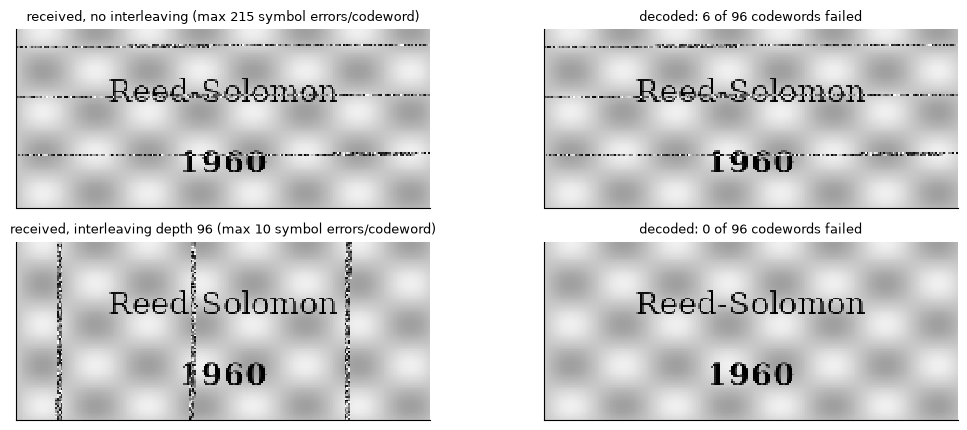

In [29]:
def make_image(h=96, w=223):
    yy, xx = np.mgrid[0:h, 0:w]
    img = 200 + 40 * np.sin(xx / 9.0) * np.cos(yy / 7.0)
    f = plt.figure(figsize=(w / 50, h / 50), dpi=50); a = f.add_axes([0, 0, 1, 1]); a.set_axis_off()
    a.text(0.5, 0.64, "Reed-Solomon", ha="center", va="center", fontsize=24, family="serif")
    a.text(0.5, 0.24, "1960", ha="center", va="center", fontsize=24, family="serif", fontweight="bold")
    f.canvas.draw(); txt = np.asarray(f.canvas.buffer_rgba())[:h, :w, :3].mean(axis=2); plt.close(f)
    return np.clip(np.where(txt < 128, txt, img), 0, 255).astype(np.int64)

img = make_image()
rs = gf.ReedSolomon(255, 223, gf.GF(8))
code = np.stack([rs.encode(row) for row in img])

def burst_demo(burst_len=300, depth=96):
    bursts = [(2100, burst_len), (9000, burst_len), (17000, burst_len)]
    def channel(stream):
        s = stream.copy()
        for st, L in bursts:
            s[st:st + L] = rng.integers(0, 256, L)
        return s
    rows_ = code.shape[0]
    out = []
    for D in (1, depth):
        groups = [code[i:i + D] for i in range(0, rows_, D)]
        stream = np.concatenate([g.T.reshape(-1) for g in groups])       # column-wise within each group
        rs_ = channel(stream)
        rx, pos = [], 0
        for g in groups:
            blk = rs_[pos:pos + g.size].reshape(g.shape[1], g.shape[0]).T; pos += g.size
            rx.append(blk)
        rx = np.vstack(rx)
        res = [rs.decode(x) for x in rx]
        dec = np.stack([m for m, _ in res])
        out.append((rx, dec, sum(n < 0 for _, n in res), int((rx != code).sum(axis=1).max())))
    f, ax = lk.fig((11, 4.4), 2, 2)
    for i, (rx, dec, fails, mx) in enumerate(out):
        lab = "no interleaving" if i == 0 else f"interleaving depth {depth}"
        ax[i, 0].imshow(rx[:, :223], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        ax[i, 0].set_title(f"received, {lab} (max {mx} symbol errors/codeword)", fontsize=9)
        ax[i, 1].imshow(dec, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        ax[i, 1].set_title(f"decoded: {fails} of {rows_} codewords failed", fontsize=9)
        for a in ax[i]:
            a.set_xticks([]); a.set_yticks([]); a.grid(False)
    lk.show(f)

lk.interact(burst_demo, burst_len=lk.islider(300, 20, 1500, 20, "burst length (bytes)"),
            depth=lk.choice([2, 4, 8, 16, 32, 48, 96], 96, "interleaver depth D"))

**What you should see.** Without interleaving each burst wipes out one or two whole rows (300 errors in a codeword that can
correct 16) and the decoder gives up on them. With depth 96 the same bursts spread to about 3–4 errors per codeword and the
image comes back perfect (at most about 10 errors in any codeword). Shrink the depth: a burst of $B$ bytes is corrected only while $\lceil B/D\rceil \le 16$ (roughly),
so $D = 16$ tolerates bursts of about 250 bytes. This is the logic of the CD's cross-interleaved RS code and of the
DVB convolutional interleaver ahead of RS(204,188).

### Try it yourself 7.1
What is the longest burst (in bytes) that a depth-$D=12$ block interleaver ahead of RS(204,188) ($t = 8$) is guaranteed to
correct, if the burst is aligned to start a column? (One column holds one byte from each of the 12 codewords.)

In [31]:
answer_7_1 = None
lk.check("7.1 longest correctable burst, D = 12, t = 8 (bytes)", answer_7_1, 12 * 8, atol=0)

[TODO] 7.1 longest correctable burst, D = 12, t = 8 (bytes): not attempted yet: replace the None with your answer

## Key takeaways
* A linear code is its $\mathbf{H}$: the syndrome depends only on the error, and $d_{\min}$ is the fewest dependent columns.
* Bounded-distance decoders correct up to $t$ and then either detect failure or miscorrect; SECDED trades correction for detection.
* A CRC is a polynomial plus conventions; it detects all short patterns by structure and all others with probability $1-2^{-r}$.
* GF($2^m$) arithmetic is XOR plus log tables; BCH and Reed–Solomon decoders are syndromes, Berlekamp–Massey, Chien and Forney.
* Reed–Solomon codes are MDS: $2\nu + e \le n-k$. Interleaving turns their burst-correcting power into protection against long bursts.

## Going further (hardware: USRP B200 / GNU Radio)
* `gnuradio/gr05_coded_link.py --sim` sends framed BPSK; add a CRC-32 (`gf.crc_bits`) per frame and log how many frames with
  residual errors the CRC catches.
* GNU Radio's `gr-dtv` contains the DVB-T RS(204,188) encoder/decoder and convolutional interleaver: compare their output with
  `gf.ReedSolomon(204, 188)` on the same bytes.

## Exercises
1. **(Warm-up)** Build the Hamming (15,11) code, list its weight distribution and verify $A_3 = 35$.
2. **(Core)** Use `gf.BCH(8, t)` to make DVB-S2-like outer codes of length 255 for $t = 2..12$, and plot rate against the
   channel bit error rate at which the word error rate reaches $10^{-6}$.
3. **(Core)** Implement a 2-state Gilbert–Elliott channel with `bc.gilbert_elliott` and compare RS(255,223) with and
   without a depth-16 interleaver at the same average symbol error rate.
4. **(Stretch)** Build a Chipkill-style code: treat the 4 bits from each DRAM chip as a GF(16) symbol and use a shortened
   RS code over GF(16) to survive the complete failure of one chip. How many check symbols do you need for 16 data symbols?

In [33]:
lk.summary()

[good] Lab 20 finished in 6.2 s. Self-checks: 0 passed, 0 failed, 6 still to do.